In [2]:
# --- Phase 2: Data Understanding — setup and first look ---
import numpy as np
import pandas as pd
from pathlib import Path

# Locate the dataset robustly, whether the notebook runs from the project
# root or from inside notebooks/. We check both possible locations.
candidates = [Path("data/UCI HAR Dataset"), Path("../data/UCI HAR Dataset")]
DATA_DIR = next((p for p in candidates if p.exists()), None)
assert DATA_DIR is not None, "Dataset not found — run: python src/download_data.py"
print("Using dataset at:", DATA_DIR.resolve())

# 1) The activity label map: numbers 1–6 -> human-readable names.
#    sep=r"\s+" means "split on whitespace" (the file is space-separated).
activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+", header=None, names=["id", "activity"]
)
print("\nActivity label map:")
print(activity_labels)

# 2) The training labels (y) and the subject IDs, one per window.
#    Each is a single column of integers, no header row.
y_train = pd.read_csv(DATA_DIR / "train/y_train.txt", header=None, names=["activity_id"])
subject_train = pd.read_csv(DATA_DIR / "train/subject_train.txt", header=None, names=["subject"])

# 3) Answer the basic "what's in here?" questions.
print("\n--- Training set overview ---")
print("Number of windows (samples):", len(y_train))
print("Number of distinct activities:", y_train["activity_id"].nunique())
print("Number of distinct subjects (people):", subject_train["subject"].nunique())
print("Subject IDs present:", sorted(subject_train["subject"].unique()))

Using dataset at: C:\Users\abel\Documents\Python_projects\The HAR project\data\UCI HAR Dataset

Activity label map:
   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING

--- Training set overview ---
Number of windows (samples): 7352
Number of distinct activities: 6
Number of distinct subjects (people): 21
Subject IDs present: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [3]:
# Map numeric activity IDs to their names so tables are readable.
id_to_activity = dict(zip(activity_labels["id"], activity_labels["activity"]))
y_train["activity"] = y_train["activity_id"].map(id_to_activity)

# Class distribution: how many windows per activity, and what share of the total.
counts = y_train["activity"].value_counts()
percent = y_train["activity"].value_counts(normalize=True).mul(100).round(1)

balance = pd.DataFrame({"count": counts, "percent (%)": percent})
print(balance)
print("\nTotal windows:", int(counts.sum()))
print("Imbalance ratio (largest class / smallest class):",
      round(counts.max() / counts.min(), 2))

                    count  percent (%)
activity                              
LAYING               1407         19.1
STANDING             1374         18.7
SITTING              1286         17.5
WALKING              1226         16.7
WALKING_UPSTAIRS     1073         14.6
WALKING_DOWNSTAIRS    986         13.4

Total windows: 7352
Imbalance ratio (largest class / smallest class): 1.43


Saved figure to: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\class_distribution.png


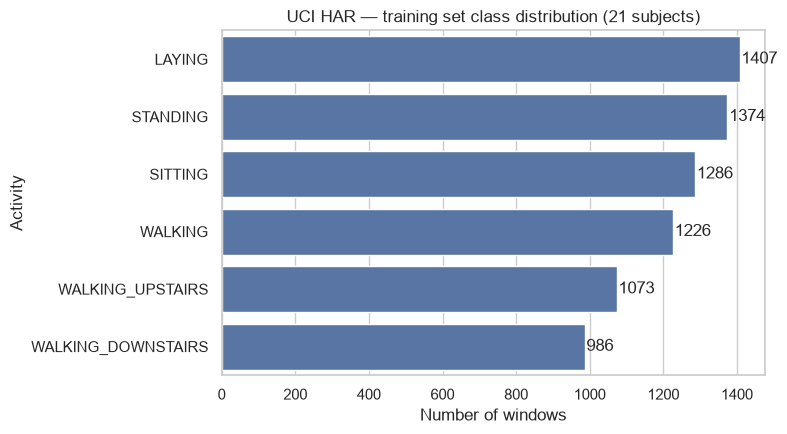

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  # clean default styling

# counts is already sorted most -> least frequent from the previous cell.
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=counts.values, y=counts.index, color="#4C72B0", ax=ax)
ax.set_xlabel("Number of windows")
ax.set_ylabel("Activity")
ax.set_title("UCI HAR — training set class distribution (21 subjects)")

# Annotate each bar with its exact count.
for i, v in enumerate(counts.values):
    ax.text(v + 5, i, str(v), va="center")

plt.tight_layout()

# Save the figure into reports/figures so it can go in the README/report later.
fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
out_path = fig_dir / "class_distribution.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved figure to:", out_path.resolve())
plt.show()

Saved figure to: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\signal_examples.png


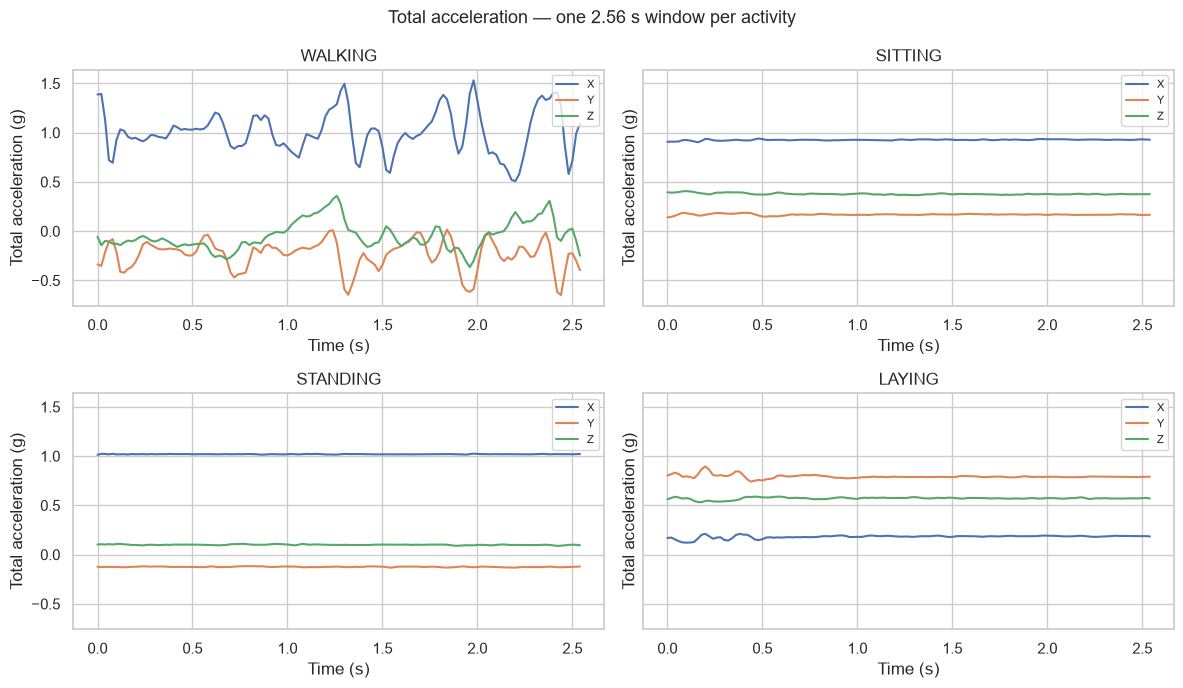

In [5]:
# Load the RAW inertial signals (the second representation of the data).
# Each file is shape (7352, 128): one row per window, 128 timesteps per row.
signals_dir = DATA_DIR / "train" / "Inertial Signals"

def load_signal(name):
    return pd.read_csv(signals_dir / f"{name}_train.txt", sep=r"\s+", header=None).values

acc_x = load_signal("total_acc_x")   # total acceleration, X axis  (units: g)
acc_y = load_signal("total_acc_y")   # total acceleration, Y axis
acc_z = load_signal("total_acc_z")   # total acceleration, Z axis

# Grab the first window belonging to a given activity.
def first_window(activity_name):
    return y_train.index[y_train["activity"] == activity_name][0]

# Compare a moving activity, the two "confusable" statics, and laying.
activities_to_show = ["WALKING", "SITTING", "STANDING", "LAYING"]

t = np.arange(128) / 50.0   # 128 samples at 50 Hz -> time in seconds (0 to 2.56 s)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, act in zip(axes.ravel(), activities_to_show):
    idx = first_window(act)
    ax.plot(t, acc_x[idx], label="X")
    ax.plot(t, acc_y[idx], label="Y")
    ax.plot(t, acc_z[idx], label="Z")
    ax.set_title(act)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Total acceleration (g)")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Total acceleration — one 2.56 s window per activity", fontsize=13)
plt.tight_layout()

fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
out_path = fig_dir / "signal_examples.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved figure to:", out_path.resolve())
plt.show()

In [6]:
# Load the 561 pre-computed features for the training set (the baseline's input).
X_train = pd.read_csv(DATA_DIR / "train/X_train.txt", sep=r"\s+", header=None)
print("Feature matrix shape:", X_train.shape)          # expect (7352, 561)

# Load the human-readable feature names.
features = pd.read_csv(DATA_DIR / "features.txt", sep=r"\s+", header=None, names=["idx", "name"])
print("Number of feature names:", len(features))
print("First 5 feature names:", features["name"].head().tolist())

# --- Data quality checks (verify, don't assume) ---
print("\n--- Data quality ---")
print("Missing values in features:", int(X_train.isna().sum().sum()))
print("Missing values in labels:  ", int(y_train["activity_id"].isna().sum()))
print("Feature value range: min =", round(X_train.values.min(), 3),
      "| max =", round(X_train.values.max(), 3))

Feature matrix shape: (7352, 561)
Number of feature names: 561
First 5 feature names: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y']

--- Data quality ---
Missing values in features: 0
Missing values in labels:   0
Feature value range: min = -1.0 | max = 1.0


In [7]:
# --- Phase 3: Data Preparation ---

# Load the TEST set the same way we loaded train.
X_test = pd.read_csv(DATA_DIR / "test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv(DATA_DIR / "test/y_test.txt", header=None, names=["activity_id"])
subject_test = pd.read_csv(DATA_DIR / "test/subject_test.txt", header=None, names=["subject"])

# Add readable activity names to the test labels too.
y_test["activity"] = y_test["activity_id"].map(id_to_activity)

print("Baseline data shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_test :", X_test.shape,  " y_test :", y_test.shape)

# --- The critical methodological check: NO subject appears in both sets ---
train_subjects = set(subject_train["subject"].unique())
test_subjects  = set(subject_test["subject"].unique())
overlap = train_subjects & test_subjects   # set intersection

print("\nTrain subjects:", len(train_subjects), "| Test subjects:", len(test_subjects))
print("Overlap (people in BOTH sets):", overlap)
assert len(overlap) == 0, "Subject leakage! A person is in both train and test."
print("PASSED: subject-independent split confirmed — test people are unseen.")

Baseline data shapes:
  X_train: (7352, 561)  y_train: (7352, 2)
  X_test : (2947, 561)  y_test : (2947, 2)

Train subjects: 21 | Test subjects: 9
Overlap (people in BOTH sets): set()
PASSED: subject-independent split confirmed — test people are unseen.


In [8]:
# The 9 raw inertial signal channels, in a fixed order.
SIGNAL_NAMES = [
    "body_acc_x",  "body_acc_y",  "body_acc_z",     # body acceleration (gravity removed)
    "body_gyro_x", "body_gyro_y", "body_gyro_z",    # angular velocity
    "total_acc_x", "total_acc_y", "total_acc_z",    # total acceleration (incl. gravity)
]

def load_inertial_tensor(split):
    """Load all 9 channels for a split into shape (n_windows, 128, 9)."""
    sig_dir = DATA_DIR / split / "Inertial Signals"
    channels = [
        pd.read_csv(sig_dir / f"{name}_{split}.txt", sep=r"\s+", header=None).values
        for name in SIGNAL_NAMES
    ]                                    # list of 9 arrays, each (n_windows, 128)
    return np.stack(channels, axis=-1)   # stack into (n_windows, 128, 9)

X_train_raw = load_inertial_tensor("train")
X_test_raw  = load_inertial_tensor("test")

print("Raw signal tensors (deep-model input):")
print("  X_train_raw:", X_train_raw.shape)   # expect (7352, 128, 9)
print("  X_test_raw :", X_test_raw.shape)    # expect (2947, 128, 9)
print("Value range: min =", round(float(X_train_raw.min()), 2),
      "| max =", round(float(X_train_raw.max()), 2))

Raw signal tensors (deep-model input):
  X_train_raw: (7352, 128, 9)
  X_test_raw : (2947, 128, 9)
Value range: min = -5.97 | max = 5.75
